<a href="https://colab.research.google.com/github/plwam/hugging_face_colab/blob/main/YOLOv8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Local Inference on GPU
Model page: https://huggingface.co/Ultralytics/YOLOv8

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/Ultralytics/YOLOv8)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [10]:
!pip install ultralytics


In [12]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt") # Changed from "Ultralytics/YOLOv8" to a local model file
source = 'http://images.cocodataset.org/val2017/000000039769.jpg'
results = model.predict(source=source, save=True)

# Pour une seule image, results est une liste, on prend le premier élément
det = results[0]

print(f"Nombre d'objets détectés : {det.boxes.shape[0]}")

# Parcourir chaque détection
for box in det.boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()   # coordonnées
    conf = box.conf[0].item()               # confiance
    cls_id = int(box.cls[0].item())         # identifiant de classe
    nom = det.names[cls_id]                 # nom de la classe
    print(f"{nom}: {conf:.2f} | boîte : ({x1:.0f}, {y1:.0f}) - ({x2:.0f}, {y2:.0f})")


Found http://images.cocodataset.org/val2017/000000039769.jpg locally at 000000039769.jpg
image 1/1 /content/000000039769.jpg: 480x640 2 cats, 1 couch, 2 remotes, 11.6ms
Speed: 3.8ms preprocess, 11.6ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict-3
Nombre d'objets détectés : 5
cat: 0.89 | boîte : (341, 26) - (640, 370)
cat: 0.82 | boîte : (11, 54) - (319, 471)
remote: 0.78 | boîte : (40, 74) - (177, 119)
couch: 0.36 | boîte : (1, 0) - (639, 480)
remote: 0.32 | boîte : (335, 77) - (371, 186)


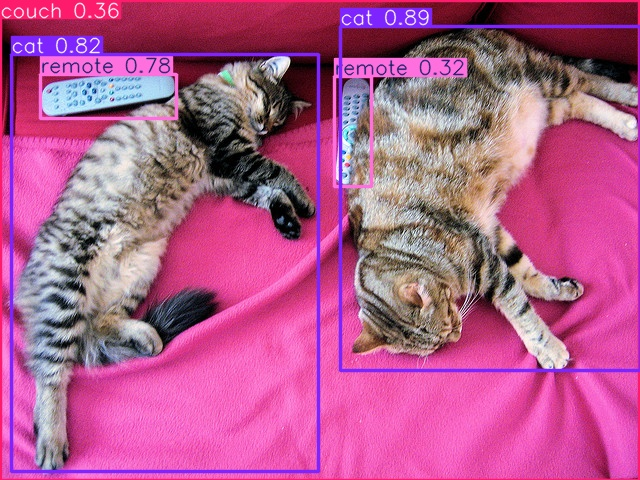

In [13]:
from IPython.display import Image

# Assuming the image is saved with its original name in the predict-3 directory
display(Image(filename='/content/runs/detect/predict-3/000000039769.jpg'))

## Affiner le modèle YOLOv8 pour la détection de déchets

Pour spécialiser le modèle YOLOv8 dans la détection de déchets (plastiques, non-plastiques) et pour différencier les humains et les animaux des déchets, vous devrez effectuer un processus de *fine-tuning* (ajustement fin). Ce processus se décompose en plusieurs étapes clés :

1.  **Préparation du jeu de données :** Collecter des images et les annoter avec les catégories spécifiques (plastique, non-plastique, humain, animal). Le format d'annotation doit être compatible avec YOLO.
2.  **Configuration du modèle :** Adapter la configuration du modèle YOLOv8 pour qu'il puisse apprendre à reconnaître vos nouvelles classes.
3.  **Entraînement du modèle :** Utiliser votre jeu de données annoté pour entraîner le modèle. Vous pouvez commencer avec un modèle pré-entraîné (comme `yolov8n.pt`) pour accélérer l'apprentissage.
4.  **Évaluation et optimisation :** Évaluer les performances du modèle et ajuster les hyperparamètres si nécessaire.

### Étape 1: Préparation du jeu de données

Vous aurez besoin d'un jeu de données d'images contenant les objets que vous souhaitez détecter (plastique, non-plastique, humain, animal). Chaque image doit avoir un fichier d'annotation correspondant au format YOLO. Ce format consiste en un fichier texte par image, où chaque ligne représente un objet détecté avec le format : `<class_id> <center_x> <center_y> <width> <height>`.

Assurez-vous que vos images et leurs fichiers d'annotation `.txt` sont organisés de cette manière (par exemple) :

```
/path/to/your/dataset
├── images
│   ├── train
│   │   ├── image1.jpg
│   │   └── image2.jpg
│   ├── val
│   │   ├── image3.jpg
│   │   └── image4.jpg
├── labels
│   ├── train
│   │   ├── image1.txt
│   │   └── image2.txt
│   ├── val
│   │   ├── image3.txt
│   │   └── image4.txt
└── data.yaml
```

Le fichier `data.yaml` est crucial et doit définir les chemins vers vos données d'entraînement et de validation, ainsi que les noms de vos classes. Voici un exemple de `data.yaml` pour votre cas :

In [ ]:
# Créez un fichier data.yaml. Vous devrez adapter les chemins et les noms de classes.
# Sauvegardez ce contenu dans un fichier nommé 'waste_detection.yaml' dans le répertoire de votre Colab.

%%writefile waste_detection.yaml
train: /path/to/your/dataset/images/train  # Chemin vers le dossier des images d'entraînement
val: /path/to/your/dataset/images/val    # Chemin vers le dossier des images de validation

# Nombre de classes
nc: 4

# Noms des classes
names: ['plastic_waste', 'non_plastic_waste', 'human', 'animal']

### Étape 2: Entraînement du modèle

Maintenant que le jeu de données est préparé et que le fichier `data.yaml` est configuré, vous pouvez entraîner le modèle YOLOv8. Nous allons charger un modèle YOLOv8 pré-entraîné (`yolov8n.pt` est un bon point de départ) et l'entraîner sur votre nouveau jeu de données.

In [ ]:
from ultralytics import YOLO

# Charger un modèle pré-entraîné YOLOv8n.
# C'est une bonne pratique de commencer par un modèle pré-entraîné pour le fine-tuning.
model = YOLO('yolov8n.pt')

# Entraîner le modèle
# 'data' pointe vers notre fichier waste_detection.yaml
# 'epochs' est le nombre d'époques d'entraînement (ajustez selon votre besoin)
# 'imgsz' est la taille de l'image (peut être ajustée)
# 'batch' est la taille du lot (ajustez en fonction de la mémoire GPU disponible)
results = model.train(data='waste_detection.yaml', epochs=50, imgsz=640, batch=16)

### Étape 3: Évaluation du modèle

Après l'entraînement, vous pouvez évaluer la performance de votre modèle fine-tuné sur votre jeu de données de validation.

In [ ]:
# Évaluer le modèle sur le jeu de données de validation
metrics = model.val()

# Afficher quelques métriques importantes
print("MAP50-95:", metrics.box.map)
print("MAP50:", metrics.box.map50)
print("MAP75:", metrics.box.map75)
print("Classes:", metrics.box.nc)
print("Noms des classes:", metrics.box.names)

### Utilisation du modèle fine-tuné

Une fois que vous êtes satisfait des performances de votre modèle, vous pouvez l'utiliser pour la prédiction comme vous l'avez fait précédemment, mais en chargeant le modèle entraîné (généralement enregistré sous `runs/detect/train/weights/best.pt` ou similaire).

In [ ]:
from ultralytics import YOLO

# Charger le modèle entraîné
# Le chemin exact peut varier, vérifiez le dossier 'runs/detect/train' après l'entraînement
model_finetuned = YOLO('/content/runs/detect/train/weights/best.pt')

# Effectuer une prédiction avec le modèle fine-tuné sur une nouvelle image
source_image_test = 'http://images.cocodataset.org/val2017/000000000009.jpg' # Remplacez par une image de test pertinente
results_finetuned = model_finetuned.predict(source=source_image_test, save=True, conf=0.25)

# Afficher les résultats (similaire à avant)
if results_finetuned:
    det_finetuned = results_finetuned[0]
    print(f"Nombre d'objets détectés : {det_finetuned.boxes.shape[0]}")
    for box in det_finetuned.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls_id = int(box.cls[0].item())
        nom = det_finetuned.names[cls_id]
        print(f"{nom}: {conf:.2f} | boîte : ({x1:.0f}, {y1:.0f}) - ({x2:.0f}, {y2:.0f})")

    # Pour afficher l'image annotée (le chemin exact dépendra du nom du dossier de prédiction)
    from IPython.display import Image
    import os

    # Trouver le dernier dossier de prédiction
    runs_dir = '/content/runs/detect/'
    all_predict_dirs = [d for d in os.listdir(runs_dir) if d.startswith('predict')]
    latest_predict_dir = sorted(all_predict_dirs)[-1] # Prend le dernier (le plus récent)

    # Construire le chemin complet de l'image annotée
    annotated_image_path = os.path.join(runs_dir, latest_predict_dir, os.path.basename(source_image_test))

    print(f"Affichage de l'image annotée depuis : {annotated_image_path}")
    display(Image(filename=annotated_image_path))
else:
    print("Aucune détection effectuée.")